## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P — Medida de desempeño** | Aprobar créditos con bajo riesgo, reducir préstamos impagos y evitar rechazar injustamente a clientes solventes. |
| **E — Entorno** | Banco, solicitudes de crédito, clientes, historial financiero y condiciones económicas. |
| **A — Actuadores** | Aprobar solicitud, aprobar con condiciones o rechazar solicitud. |
| **S — Percepciones** | Ingreso mensual, monto solicitado y existencia de historial moroso. |
| **Objetivo** | Tomar una decisión de crédito responsable según la capacidad de pago y el riesgo del solicitante. |
| **Tipo de agente** | Agente reactivo simple, porque decide usando las percepciones actuales y reglas predefinidas. |

### Justificación de las reglas

El banco debe comparar el monto solicitado con el ingreso mensual porque una relación alta representa una mayor dificultad de pago. Se aprueba una solicitud cuando la relación es baja y el cliente no tiene historial moroso. Si existe un riesgo moderado, se puede aprobar con condiciones, como solicitar documentos adicionales o reducir el monto. Cuando el monto solicitado es demasiado alto o existe morosidad con riesgo elevado, se rechaza para disminuir las posibles pérdidas del banco.

### Código

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    if ingreso_mensual <= 0:
        return "rechazar", "el ingreso mensual debe ser mayor que cero"

    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso and relacion > 0.30:
        return "rechazar", "historial moroso y relacion monto/ingreso mayor a 0.30"

    elif relacion > 0.50:
        return "rechazar", "relacion monto/ingreso mayor a 0.50"

    elif tiene_historial_moroso:
        return "aprobar con condiciones", "historial moroso, pero la relacion monto/ingreso es manejable"

    elif relacion <= 0.30:
        return "aprobar", "relacion monto/ingreso baja y sin historial moroso"

    else:
        return "aprobar con condiciones", "relacion monto/ingreso moderada; requiere condiciones adicionales"

### Simulación y pruebas

In [2]:
casos_credito = [
    (3000, 600, False),   # Relación 0.20: aprobar
    (3000, 900, False),   # Relación 0.30: caso límite, aprobar
    (3000, 1200, False),  # Relación 0.40: aprobar con condiciones
    (3000, 1500, False),  # Relación 0.50: caso límite, aprobar con condiciones
    (3000, 1800, False),  # Relación 0.60: rechazar
    (3000, 1200, True),   # Relación 0.40 con morosidad: rechazar
]

for ingreso, monto, moroso in casos_credito:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso

    print(f"Ingreso mensual: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Relación monto/ingreso: {relacion:.2f}")
    print(f"Historial moroso: {moroso}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 70)

Ingreso mensual: S/ 3000
Monto solicitado: S/ 600
Relación monto/ingreso: 0.20
Historial moroso: False
Decisión: aprobar
Motivo: relacion monto/ingreso baja y sin historial moroso
----------------------------------------------------------------------
Ingreso mensual: S/ 3000
Monto solicitado: S/ 900
Relación monto/ingreso: 0.30
Historial moroso: False
Decisión: aprobar
Motivo: relacion monto/ingreso baja y sin historial moroso
----------------------------------------------------------------------
Ingreso mensual: S/ 3000
Monto solicitado: S/ 1200
Relación monto/ingreso: 0.40
Historial moroso: False
Decisión: aprobar con condiciones
Motivo: relacion monto/ingreso moderada; requiere condiciones adicionales
----------------------------------------------------------------------
Ingreso mensual: S/ 3000
Monto solicitado: S/ 1500
Relación monto/ingreso: 0.50
Historial moroso: False
Decisión: aprobar con condiciones
Motivo: relacion monto/ingreso moderada; requiere condiciones adicionales
---

### Visualización

Se generan 200 solicitudes de crédito aleatorias. Cada punto representa una solicitud; el eje horizontal representa la relación entre el monto solicitado y el ingreso mensual, mientras que el eje vertical muestra el ingreso mensual. El color representa la decisión tomada por el agente.

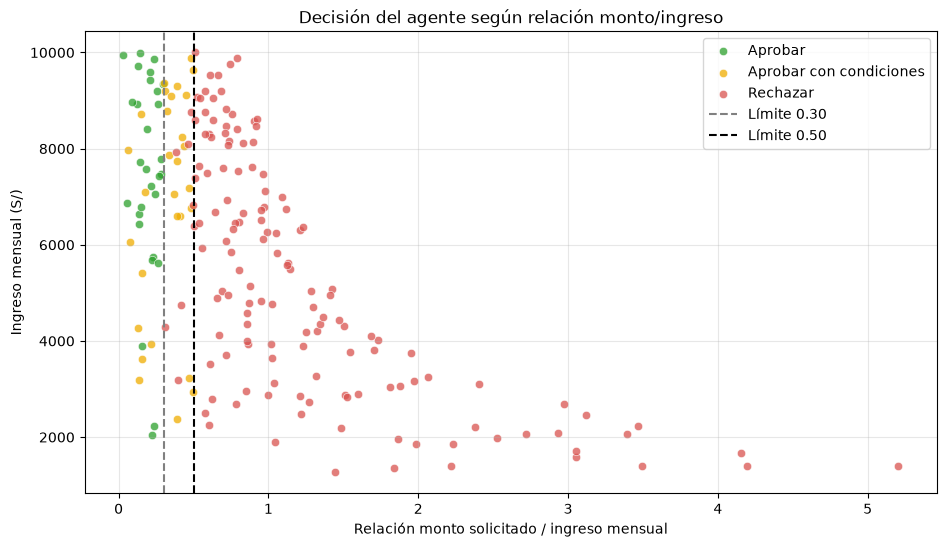

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200

ingresos = np.random.randint(1200, 10001, n)
montos = np.random.randint(300, 8001, n)
historiales_morosos = np.random.choice(
    [True, False],
    n,
    p=[0.30, 0.70]
)

relaciones = montos / ingresos
decisiones = []

for ingreso, monto, moroso in zip(ingresos, montos, historiales_morosos):
    accion, motivo = agente_credito(ingreso, monto, moroso)
    decisiones.append(accion)

colores = {
    "aprobar": "#2ca02c",
    "aprobar con condiciones": "#f0ad00",
    "rechazar": "#d9534f"
}

plt.figure(figsize=(11, 6))

for decision, color in colores.items():
    indices = [
        i for i, accion in enumerate(decisiones)
        if accion == decision
    ]

    plt.scatter(
        relaciones[indices],
        ingresos[indices],
        c=color,
        label=decision.capitalize(),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.5
    )

plt.axvline(0.30, color="gray", linestyle="--", label="Límite 0.30")
plt.axvline(0.50, color="black", linestyle="--", label="Límite 0.50")

plt.title("Decisión del agente según relación monto/ingreso")
plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()